<a href="https://colab.research.google.com/github/GOKULA-127/TEXTMINING-PROJECT/blob/main/text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install beautifulsoup4 requests nltk scikit-learn seaborn

In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

--2026-04-13 16:58:19--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29470338 (28M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  28.10M   154MB/s    in 0.2s    

2026-04-13 16:58:20 (154 MB/s) - ‘train.csv’ saved [29470338/29470338]



In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
0,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
1,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
2,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
3,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
4,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...


In [ ]:
df = pd.read_csv("train.csv", header=None)
df.columns = ["label", "title", "description"]

In [ ]:
df["text"] = df["title"] + " " + df["description"]

label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Technology"
}

df = df[df["label"].isin(label_map.keys())]
df["category"] = df["label"].map(label_map)

df = df[["text", "category"]]

# Reduce size for speed (optional)
df = df.sample(15000)

In [ ]:
print("Total samples:", len(df))
print(df["category"].value_counts())

Total samples: 15000
category
Business      3811
Sports        3796
Technology    3725
World         3668
Name: count, dtype: int64


In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    words = text.lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess)

In [ ]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = vectorizer.fit_transform(df["clean_text"])
y = df["category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y
)

In [ ]:
import pandas as pd
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}
trained_models = {}
training_time = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)

    trained_models[name] = model
    training_time[name] = round(end - start, 4)

    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average='weighted'), 4),
        "Recall": round(recall_score(y_test, y_pred, average='weighted'), 4),
        "F1 Score": round(f1_score(y_test, y_pred, average='weighted'), 4)
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# Add training time
results_df["Training Time (s)"] = pd.Series(training_time)

# Display nicely
print("\n===== MODEL COMPARISON =====")
print(results_df)


Training k-NN...

Training SVM...

===== MODEL COMPARISON =====
      Accuracy  Precision  Recall  F1 Score  Training Time (s)
k-NN    0.8242     0.8261  0.8242    0.8237             0.0111
SVM     0.8740     0.8740  0.8740    0.8738            17.6600


In [ ]:
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    print("\n====================")
    print(name)
    print("====================")
    print(classification_report(y_test, model.predict(X_test)))


k-NN
              precision    recall  f1-score   support

    Business       0.76      0.82      0.79      1143
      Sports       0.85      0.92      0.88      1139
  Technology       0.82      0.75      0.78      1118
       World       0.88      0.80      0.84      1100

    accuracy                           0.82      4500
   macro avg       0.83      0.82      0.82      4500
weighted avg       0.83      0.82      0.82      4500


SVM
              precision    recall  f1-score   support

    Business       0.83      0.85      0.84      1143
      Sports       0.93      0.95      0.94      1139
  Technology       0.85      0.82      0.84      1118
       World       0.89      0.87      0.88      1100

    accuracy                           0.87      4500
   macro avg       0.87      0.87      0.87      4500
weighted avg       0.87      0.87      0.87      4500



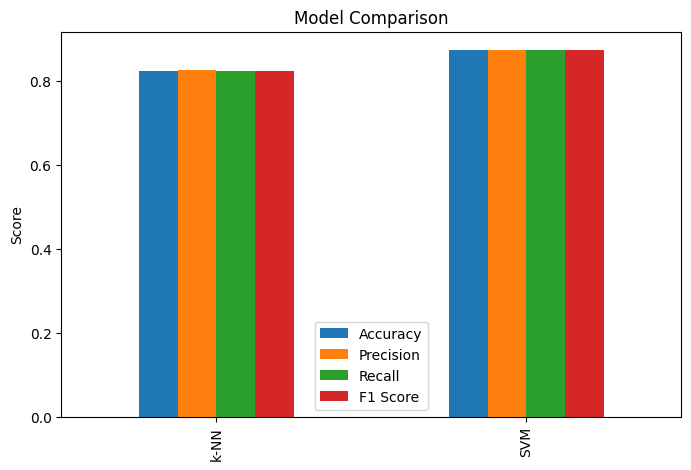

In [ ]:
results_df.drop(columns=["Training Time (s)"]).plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

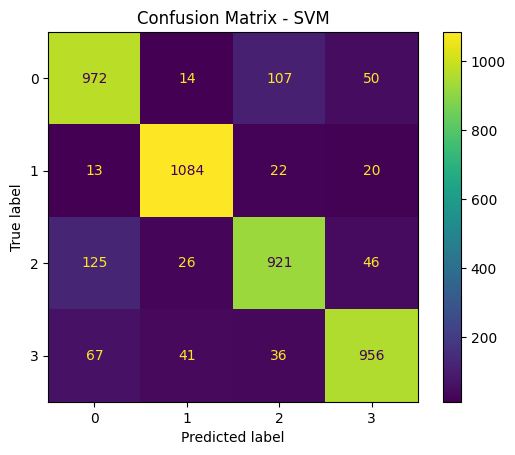

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = trained_models["SVM"].predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
svm_model = trained_models["SVM"]

In [ ]:
import requests
from bs4 import BeautifulSoup

def extract_content(url):
    try:
        response = requests.get(url, timeout=5)
        soup = BeautifulSoup(response.text, 'html.parser')

        title = soup.title.string if soup.title else ""

        desc = soup.find("meta", attrs={"name": "description"})
        description = desc.get("content", "") if desc else ""

        return title + " " + description

    except:
        return ""

In [ ]:
def predict_url_svm(url):
    text = extract_content(url)

    if text.strip() == "":
        print("⚠️ Could not extract content from URL")
        return

    clean = preprocess(text)
    vector = vectorizer.transform([clean])

    prediction = svm_model.predict(vector)[0]

    print("\n🌐 URL:", url)
    print("📄 Extracted Text:", text[:150], "...")
    print("🔍 Predicted Category (SVM):", prediction)

In [ ]:
predict_url_svm("https://www.apple.com")
predict_url_svm("https://www.espn.com")
predict_url_svm("https://www.bbc.com/news")


🌐 URL: https://www.apple.com
📄 Extracted Text: Apple  ...
🔍 Predicted Category (SVM): Technology

🌐 URL: https://www.espn.com
📄 Extracted Text: ERROR: The request could not be satisfied  ...
🔍 Predicted Category (SVM): Technology

🌐 URL: https://www.bbc.com/news
📄 Extracted Text: BBC News - Breaking news, video and the latest top stories from the U.S. and around the world Visit BBC News for the latest news, breaking news, video ...
🔍 Predicted Category (SVM): Business


In [ ]:
def predict_url_svm(url):
    text = extract_content(url)
    clean = preprocess(text)
    vector = vectorizer.transform([clean])

    prediction = svm_model.predict(vector)[0]

    if hasattr(svm_model, "decision_function"):
        confidence = svm_model.decision_function(vector).max()
    else:
        confidence = "N/A"

    print("\n🌐 URL:", url)
    print("🔍 Prediction:", prediction)
    print("📊 Confidence:", confidence)

In [ ]:
predict_url_svm("https://www.apple.com")
predict_url_svm("https://www.espn.com")
predict_url_svm("https://www.bbc.com/news")


🌐 URL: https://www.apple.com
🔍 Prediction: Technology
📊 Confidence: 3.266391347397595

🌐 URL: https://www.espn.com
🔍 Prediction: Technology
📊 Confidence: 3.189518849614115

🌐 URL: https://www.bbc.com/news
🔍 Prediction: Business
📊 Confidence: 3.188641358008502
